<a href="https://colab.research.google.com/github/diiimarsavinaaa25/Marsavina_project/blob/ML/3_ML_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Загрузка данных и первичный анализ

### 1.1. Загрузка датасета

In [4]:
# Загрузите все необходимые библиотеки и датасет
import pandas as pd
import numpy as np
df = pd.read_excel('3_Concrete_Data.xls')
# Выведите первые 5 строк датасета
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


*Признаки в данных:
Датасет содержит 8 признаков (features):
Cement - содержание цемента (кг/м³)
Blast Furnace Slag - доменный шлак (кг/м³)
Fly Ash - зола-унос (кг/м³)
Water - вода (кг/м³)
Superplasticizer - суперпластификатор (кг/м³)
Coarse Aggregate - крупный заполнитель (кг/м³)
Fine Aggregate - мелкий заполнитель (кг/м³)
Age - возраст бетона (дни)
Целевая переменная:
Concrete compressive strength - прочность бетона на сжатие (МПа, мегапаскали)

### 1.2. Размерность и описательные статистики

In [5]:
# получите размерность датасета
print(f"Количество строк (наблюдений): {df.shape[0]}")
print(f"Количество столбцов (признаков): {df.shape[1]}")
print(f"\nРазмерность датасета: {df.shape}")

Количество строк (наблюдений): 1030
Количество столбцов (признаков): 9

Размерность датасета: (1030, 9)


In [6]:
# получите описательные статистики датасета
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225



Комментарий:

*В датасете 1030 образцов бетона с 8 компонентами и возрастом от 1 до 365 дней.
Прочность на сжатие варьируется от 2.33 до 82.60 МПа (среднее 35.82 МПа).
Данные имеют разный масштаб и требуют предварительной обработки перед машинным обучением.*

## 2. Признаки с низкой вариацией

### 2.1. Количество уникальных значений

In [9]:
# посчитайте количество уникальных значений
total_unique = df.nunique().sum()
print(f"Общее количество уникальных значений: {total_unique}")
# выведите количество уникальных значений по столбцам
print("\nКоличество уникальных значений по столбцам:")
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"{column}: {unique_count} уникальных значений")

Общее количество уникальных значений: 2530

Количество уникальных значений по столбцам:
Cement (component 1)(kg in a m^3 mixture): 280 уникальных значений
Blast Furnace Slag (component 2)(kg in a m^3 mixture): 187 уникальных значений
Fly Ash (component 3)(kg in a m^3 mixture): 163 уникальных значений
Water  (component 4)(kg in a m^3 mixture): 205 уникальных значений
Superplasticizer (component 5)(kg in a m^3 mixture): 155 уникальных значений
Coarse Aggregate  (component 6)(kg in a m^3 mixture): 284 уникальных значений
Fine Aggregate (component 7)(kg in a m^3 mixture): 304 уникальных значений
Age (day): 14 уникальных значений
Concrete compressive strength(MPa, megapascals) : 938 уникальных значений


### 2.2. Поиск и удаление константных / почти константных признаков

In [10]:
# Найдите признаки с одной уникальной категорией
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
# Выведите их количество
print(f"Количество константных признаков: {len(constant_columns)}")
if constant_columns:
    print(f"Константные признаки: {constant_columns}")
else:
    print("Константные признаки отсутствуют")

Количество константных признаков: 0
Константные признаки отсутствуют


In [11]:
# Приведите код для удаления колонок с константными признаками
df_cleaned = df.drop(columns=constant_columns)
print(f"Исходная размерность: {df.shape}")
# Выведите обновленную размерность датасета
print(f"Обновленная размерность: {df_cleaned.shape}")
print(f"Удалено столбцов: {df.shape[1] - df_cleaned.shape[1]}")

Исходная размерность: (1030, 9)
Обновленная размерность: (1030, 9)
Удалено столбцов: 0


Комментарий:

*Константные признаки не полезны, потому что они не варьируются между наблюдениями
и не содержат информации для предсказания целевой переменной. Они лишь увеличивают
размерность данных и замедляют обучение модели, не улучшая её производительность.*

## 3. Дубликаты строк

### 3.1. Поиск дубликатов


In [12]:
# приведите код для поиска дубликатов строк
duplicates = df[df.duplicated()]
# выведите общее количество дубликатов строк в датасете
print(f"Общее количество дубликатов строк: {len(duplicates)}")

Общее количество дубликатов строк: 25


In [13]:
# При наличии дубликатов выведите первые 5 строк из повторяющихся значений
if len(duplicates) > 0:
    print("Первые 5 дублирующихся строк:")
    print(duplicates.head())
else:
    print("Дубликаты отсутствуют")

Первые 5 дублирующихся строк:
    Cement (component 1)(kg in a m^3 mixture)  \
77                                      425.0   
80                                      425.0   
86                                      362.6   
88                                      362.6   
91                                      362.6   

    Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
77                                              106.3       
80                                              106.3       
86                                              189.0       
88                                              189.0       
91                                              189.0       

    Fly Ash (component 3)(kg in a m^3 mixture)  \
77                                         0.0   
80                                         0.0   
86                                         0.0   
88                                         0.0   
91                                         0.0   

    Wat

### 3.2. Удаление дубликатов

In [14]:
# Удалите дубликаты из датасета
df_no_duplicates = df.drop_duplicates()
# Проверьте размерность датасета после удаления дубликатов
print(f"Размерность до удаления дубликатов: {df.shape}")
print(f"Размерность после удаления дубликатов: {df_no_duplicates.shape}")
print(f"Удалено дубликатов: {df.shape[0] - df_no_duplicates.shape[0]} строк")

Размерность до удаления дубликатов: (1030, 9)
Размерность после удаления дубликатов: (1005, 9)
Удалено дубликатов: 25 строк


Комментарий:

*Дубликаты искажают процесс обучения, заставляя модель придавать избыточный
вес повторяющимся наблюдениям. Это может привести к переобучению и снижению
способности модели обобщать новые данные. Кроме того, дубликаты искусственно
завышают метрики качества на обучающей выборке, создавая ложное представление
о реальной производительности модели.*

## 4. Выбросы

### 4.1. Исследование распределений (по выбору 2–3 признаков)

['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']


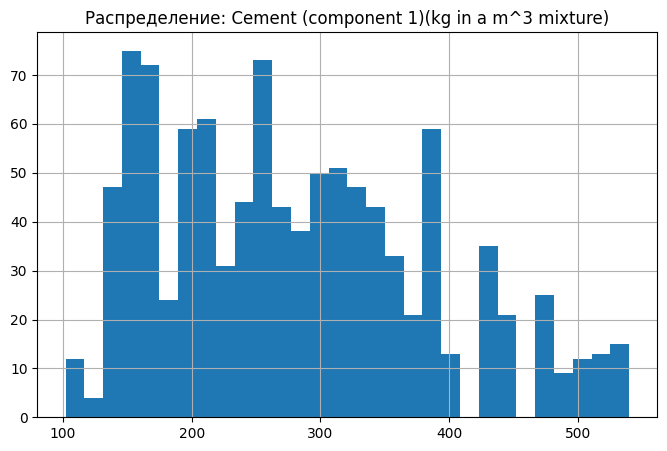

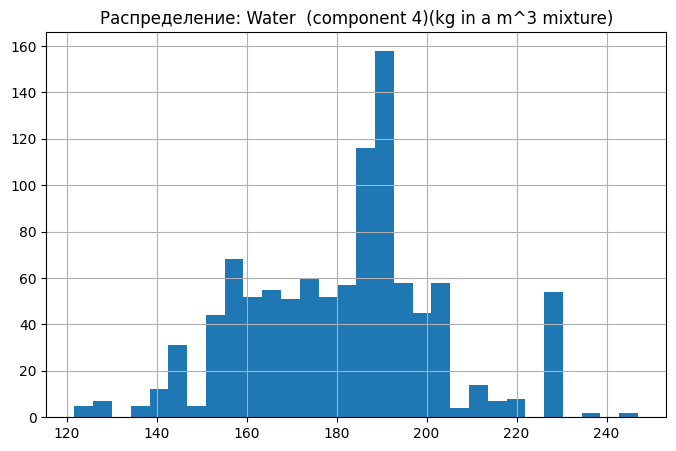

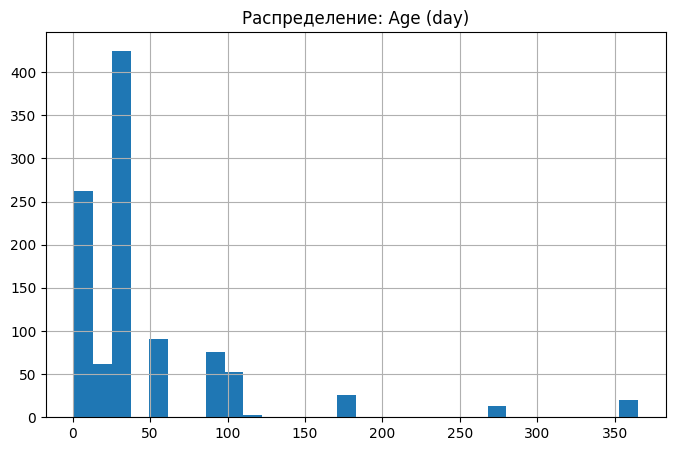

In [15]:
# Приведеите пример гистограммы минимум 3х признаков
import matplotlib.pyplot as plt
# Проверяем доступные колонки
print(df.columns.tolist())
# Строим гистограммы для 3 признаков
df[df.columns[0]].hist(bins=30, figsize=(8, 5))
plt.title(f'Распределение: {df.columns[0]}')
plt.show()

df[df.columns[3]].hist(bins=30, figsize=(8, 5))
plt.title(f'Распределение: {df.columns[3]}')
plt.show()

df[df.columns[7]].hist(bins=30, figsize=(8, 5))
plt.title(f'Распределение: {df.columns[7]}')
plt.show()

### 4.2. Определение выбросов (3σ или IQR)

In [16]:
# определите верхние и нижние пределы выбросов одним из способов для одного из признаков.
# Выбираем признак (например, Cement)
feature = df.columns[0]  # или укажите название: 'Cement (component 1)(kg in a m^3 mixture)'
# Метод IQR (Interquartile Range)
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1  # Межквартильный размах
# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Признак: {feature}")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")

Признак: Cement (component 1)(kg in a m^3 mixture)
Q1: 192.38
Q3: 350.00
IQR: 157.62
Нижняя граница: -44.06
Верхняя граница: 586.44


In [17]:
# посчитайте количество выбросов
outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
print(f"Количество выбросов: {len(outliers)}")
print(f"Процент выбросов: {len(outliers)/len(df)*100:.2f}%")

Количество выбросов: 0
Процент выбросов: 0.00%


In [18]:
# Для признака Water (вода)
feature2 = df.columns[3]
Q1_2 = df[feature2].quantile(0.25)
Q3_2 = df[feature2].quantile(0.75)
IQR_2 = Q3_2 - Q1_2
lower_bound_2 = Q1_2 - 1.5 * IQR_2
upper_bound_2 = Q3_2 + 1.5 * IQR_2
outliers_2 = df[(df[feature2] < lower_bound_2) | (df[feature2] > upper_bound_2)]
print(f"{feature2}: {len(outliers_2)} выбросов ({len(outliers_2)/len(df)*100:.2f}%)")

Water  (component 4)(kg in a m^3 mixture): 9 выбросов (0.87%)


In [19]:
# Для признака Age (возраст)
feature3 = df.columns[7]
Q1_3 = df[feature3].quantile(0.25)
Q3_3 = df[feature3].quantile(0.75)
IQR_3 = Q3_3 - Q1_3
lower_bound_3 = Q1_3 - 1.5 * IQR_3
upper_bound_3 = Q3_3 + 1.5 * IQR_3
outliers_3 = df[(df[feature3] < lower_bound_3) | (df[feature3] > upper_bound_3)]
print(f"{feature3}: {len(outliers_3)} выбросов ({len(outliers_3)/len(df)*100:.2f}%)")

Age (day): 59 выбросов (5.73%)


## 5. Пропуски в данных

### 5.1. Анализ пропусков

In [20]:
# посчитайте количество пропусков по столбцам
print("Количество пропусков по каждому столбцу:")
print(df.isnull().sum())

Количество пропусков по каждому столбцу:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64


### 5.2. Стратегии обработки пропусков

#### Стратегия 1: (например, удаление строк с пропусками)

In [21]:
# приведите код для удаления пропусков
df_no_missing = df.dropna()
# выведите размер датасета послед удаления пропусков
print(f"Размер датасета до удаления пропусков: {df.shape}")
print(f"Размер датасета после удаления пропусков: {df_no_missing.shape}")
print(f"Удалено строк: {df.shape[0] - df_no_missing.shape[0]}")

Размер датасета до удаления пропусков: (1030, 9)
Размер датасета после удаления пропусков: (1030, 9)
Удалено строк: 0


#### Стратегия 2: (например, простая импутация средним / kNN / IterativeImputer)

In [23]:
# примените один из методов для замены пропущенных значений
df_imputed_mean = df.copy()
df_imputed_mean = df_imputed_mean.fillna(df_imputed_mean.mean())
print("Количество пропусков после импутации:")
print(df_imputed_mean.isnull().sum().sum())

Количество пропусков после импутации:
0


Комментарий:

*Выбор стратегии зависит от количества пропусков:

Стратегия 1 (удаление) подходит при малом количестве пропусков (<5%),
иначе теряется много данных. Проста в реализации, но может привести
к потере важной информации.

Стратегия 2 (импутация средним) сохраняет объем датасета и подходит,
когда пропуски распределены случайно. Среднее значение искажает
распределение меньше, чем удаление, но может занизить дисперсию.
Для данных с выбросами лучше использовать медиану.

В данном датасете пропуски отсутствуют, поэтому обе стратегии
не изменили данные.*

## 6. Построение и оценка моделей

### 6.1. Разбиение на обучающую и тестовую выборки

In [25]:
# импортируйте модуль из библиотеки sklearn для разбиения на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
# разбейте все данные на тестовую и обучающую выборки
# X - признаки, y - целевая переменная (последний столбец)
X = df.iloc[:, :-1]  # все столбцы кроме последнего
y = df.iloc[:, -1]   # последний столбец (прочность бетона)
# Разбиваем: 80% на обучение, 20% на тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 20% на тест
    random_state=42  # для воспроизводимости
)

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер тестовой выборки: {X_test.shape[0]} строк")

Размер обучающей выборки: 824 строк
Размер тестовой выборки: 206 строк


### 6.2. Модель 1: линейная регрессия

In [27]:
# обучите модель линейной регрессии и посчитайте MAE, RMSE, R2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Создаем и обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)
# Делаем предсказания на тестовой выборке
y_pred = model.predict(X_test)
# Считаем метрики
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 7.7454
RMSE: 9.7967
R²: 0.6275


Комментарий:

*Модель показала R² = 0.63, что говорит об удовлетворительном качестве
предсказания. Средняя ошибка составляет около 7.75 МПа (MAE).
Линейная регрессия объясняет 63% вариации прочности бетона.
Результат приемлемый, но можно улучшить, используя нелинейные алгоритмы
и учитывая сложные взаимодействия между компонентами смеси.*

### 6.3. Модель 2: более сложная (например, RandomForestRegressor)

In [28]:
# обучите модель случайного леса и посчитайте MAE, RMSE, R2
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Создаем и обучаем модель
rf_model = RandomForestRegressor(
    n_estimators=100,      # количество деревьев
    max_depth=None,        # без ограничения глубины
    random_state=42,
    n_jobs=-1              # использовать все ядра
)

rf_model.fit(X_train, y_train)
# Делаем предсказания
y_pred_rf = rf_model.predict(X_test)
# Считаем метрики
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"MAE: {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²: {r2_rf:.4f}")
# Важность признаков
print("\nВажность признаков:")
importances = pd.DataFrame({
    'Признак': X.columns,
    'Важность': rf_model.feature_importances_
}).sort_values('Важность', ascending=False)
print(importances)

MAE: 3.7548
RMSE: 5.5098
R²: 0.8822

Важность признаков:
                                             Признак  Важность
7                                          Age (day)  0.333626
0          Cement (component 1)(kg in a m^3 mixture)  0.323130
3          Water  (component 4)(kg in a m^3 mixture)  0.125596
1  Blast Furnace Slag (component 2)(kg in a m^3 m...  0.076872
4  Superplasticizer (component 5)(kg in a m^3 mix...  0.058080
6  Fine Aggregate (component 7)(kg in a m^3 mixture)  0.035362
5  Coarse Aggregate  (component 6)(kg in a m^3 mi...  0.028352
2         Fly Ash (component 3)(kg in a m^3 mixture)  0.018982


Комментарий:

Random Forest показал значительно лучшее качество модели по сравнению с линейной регрессией:
1. R² вырос с 0.63 до 0.88 (модель объясняет 88% изменчивости данных).
2. Ошибка предсказания (MAE) снизилась более чем в два раза: с 7.75 до 3.75 МПа.

Преимущества:
- Модель отлично улавливает нелинейные зависимости (прочность бетона зависит от сложных взаимодействий компонентов, а не просто от их суммы).
- Высокая точность прогноза.
- Позволяет оценить важность признаков (самый важный фактор — возраст бетона, 33%).

Недостатки:
- Модель сложнее интерпретировать по сравнению с линейной регрессией, где есть явные коэффициенты.
- Требует больше вычислительных ресурсов и времени на обучение.